In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("../data/NF-UNSW-NB15-v3.csv")

## Display first 5 rows of the dataset

In [3]:
df.head()

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,...,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1424242193040,1424242193043,59.166.0.2,4894,149.171.126.3,53,17,5.0,146,2,...,0,0,0,0,0,0,0,0,0,Benign
1,1424242192744,1424242193079,59.166.0.4,52671,149.171.126.6,31992,6,11.0,4704,28,...,0,91,12,19,0,90,12,19,0,Benign
2,1424242190649,1424242193109,59.166.0.0,47290,149.171.126.9,6881,6,37.0,13662,238,...,0,1843,10,119,0,1843,5,88,0,Benign
3,1424242193145,1424242193146,59.166.0.8,43310,149.171.126.7,53,17,5.0,146,2,...,0,0,0,0,0,0,0,0,0,Benign
4,1424242193239,1424242193241,59.166.0.1,45870,149.171.126.1,53,17,5.0,130,2,...,0,0,0,0,0,0,0,0,0,Benign


## Show summary of dataframe

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2365424 entries, 0 to 2365423
Data columns (total 55 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   FLOW_START_MILLISECONDS      int64  
 1   FLOW_END_MILLISECONDS        int64  
 2   IPV4_SRC_ADDR                object 
 3   L4_SRC_PORT                  int64  
 4   IPV4_DST_ADDR                object 
 5   L4_DST_PORT                  int64  
 6   PROTOCOL                     int64  
 7   L7_PROTO                     float64
 8   IN_BYTES                     int64  
 9   IN_PKTS                      int64  
 10  OUT_BYTES                    int64  
 11  OUT_PKTS                     int64  
 12  TCP_FLAGS                    int64  
 13  CLIENT_TCP_FLAGS             int64  
 14  SERVER_TCP_FLAGS             int64  
 15  FLOW_DURATION_MILLISECONDS   int64  
 16  DURATION_IN                  int64  
 17  DURATION_OUT                 int64  
 18  MIN_TTL                      int64  
 19  

## Descriptive statistics for numerical columns

In [6]:
df.describe()

c:\Users\Lizzie\OneDrive\Documents\TF-ML-NIDS\venv\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\Lizzie\OneDrive\Documents\TF-ML-NIDS\venv\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,L4_SRC_PORT,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,...,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label
count,2.365424e+06,2.365424e+06,2.365424e+06,2.365424e+06,2.365424e+06,2.365424e+06,2.365424e+06,2.365424e+06,2.365424e+06,2.365424e+06,...,2.365424e+06,2.365424e+06,2.365424e+06,2.365424e+06,2.365424e+06,2.365424e+06,2.365424e+06,2.365424e+06,2.365424e+06,2.365424e+06
mean,1.423141e+12,1.423141e+12,3.266052e+04,1.114841e+04,8.730817e+00,2.353191e+01,4.413591e+03,3.528169e+01,3.432003e+04,4.471138e+01,...,3.876694e+01,5.734421e+00,2.199381e+02,2.454328e+01,4.531432e+01,5.853919e-03,2.130223e+02,1.672691e+01,4.101957e+01,5.398313e-02
std,1.144853e+09,1.144853e+09,1.915897e+04,1.839424e+04,6.384764e+00,2.126820e+01,6.769945e+04,7.839349e+01,1.550732e+05,1.163444e+02,...,8.538635e+01,2.530600e+02,8.633155e+02,2.674866e+02,2.013962e+02,1.712698e+00,7.537504e+02,6.296326e+01,1.274768e+02,2.259845e-01
min,1.421927e+12,1.421927e+12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.421951e+12,1.421951e+12,1.592700e+04,2.500000e+01,6.000000e+00,5.000000e+00,4.810000e+02,4.000000e+00,3.120000e+02,4.000000e+00,...,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.424221e+12,1.424221e+12,3.281500e+04,8.000000e+01,6.000000e+00,3.600000e+01,1.580000e+03,1.600000e+01,2.456000e+03,1.800000e+01,...,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
75%,1.424242e+12,1.424242e+12,4.910000e+04,1.462925e+04,6.000000e+00,3.700000e+01,3.048000e+03,4.400000e+01,1.437000e+04,4.200000e+01,...,0.000000e+00,0.000000e+00,1.510000e+02,1.400000e+01,3.400000e+01,0.000000e+00,1.560000e+02,1.300000e+01,3.700000e+01,0.000000e+00
max,1.424263e+12,1.424263e+12,6.553500e+04,6.553500e+04,2.550000e+02,4.210000e+02,2.702093e+07,2.016600e+04,1.465675e+07,1.102400e+04,...,5.010000e+02,6.059800e+04,6.059800e+04,3.029900e+04,3.029900e+04,1.490000e+03,6.059800e+04,2.019900e+04,2.856600e+04,1.000000e+00


## Check for missing values in each column

In [20]:
df.isnull().sum()

FLOW_START_MILLISECONDS            0
FLOW_END_MILLISECONDS              0
IPV4_SRC_ADDR                      0
L4_SRC_PORT                        0
IPV4_DST_ADDR                      0
L4_DST_PORT                        0
PROTOCOL                           0
L7_PROTO                           0
IN_BYTES                           0
IN_PKTS                            0
OUT_BYTES                          0
OUT_PKTS                           0
TCP_FLAGS                          0
CLIENT_TCP_FLAGS                   0
SERVER_TCP_FLAGS                   0
FLOW_DURATION_MILLISECONDS         0
DURATION_IN                        0
DURATION_OUT                       0
MIN_TTL                            0
MAX_TTL                            0
LONGEST_FLOW_PKT                   0
SHORTEST_FLOW_PKT                  0
MIN_IP_PKT_LEN                     0
MAX_IP_PKT_LEN                     0
SRC_TO_DST_SECOND_BYTES        63425
DST_TO_SRC_SECOND_BYTES            0
RETRANSMITTED_IN_BYTES             0
R

## Get the number of rows and columns in the dataframe

In [8]:
df.shape

(2365424, 55)

## Check if Label column exists

In [9]:
'Label' in df.columns

True

## Identify all unique values in the Label column

In [10]:
df['Label'].unique()

array([0, 1])

## Count the number of occurrences of each label (0=benign, 1=attack)

In [11]:
label_counts = df['Label'].value_counts()
label_counts

Label
0    2237731
1     127693
Name: count, dtype: int64

## Plot results

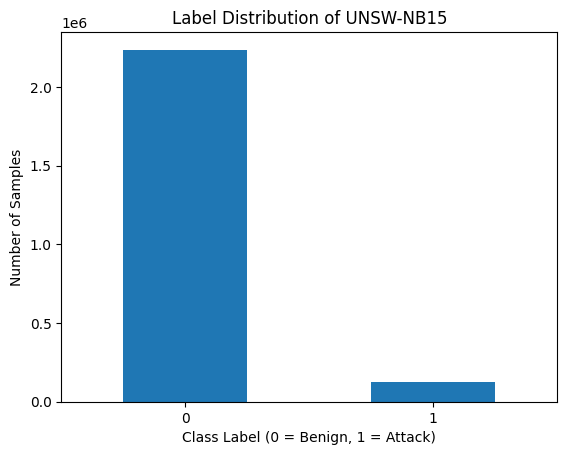

In [23]:
plt.figure()
label_counts.plot(kind='bar')
plt.title('Label Distribution of UNSW-NB15')
plt.xlabel('Class Label (0 = Benign, 1 = Attack)')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.show()